# 📊 ApexPlanet Internship — Task 2
## Exploratory Data Analysis (EDA) & Business Intelligence

---
##  Step 1 — Install & Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

# Create plots folder
os.makedirs('plots', exist_ok=True)

print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


In [11]:
# Load dataset  (use cleaned_dataset.csv if Task 1 is done, else use raw)
df = pd.read_csv('cleaned_customer_credit_data.csv')

# Quick fixes from Task 1 cleaning (run this if using raw dataset)
df['Income'].fillna(df['Income'].median(), inplace=True)
df['Loan_Balance'].fillna(df['Loan_Balance'].median(), inplace=True)
df['Credit_Score'].fillna(df['Credit_Score'].median(), inplace=True)

# Standardize Employment_Status
status_map = {'EMP': 'Employed', 'employed': 'Employed', 'retired': 'Retired'}
df['Employment_Status'] = df['Employment_Status'].replace(status_map)

print('Dataset Shape:', df.shape)
df.head()

Dataset Shape: (500, 20)


,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6,Age_Group
0,cust0001,56,165580.0,398.0,0.390502,3,0,16310.0,0.317396,emp,18,student,los angeles,late,late,missed,late,missed,late,Senior
1,cust0002,69,100999.0,493.0,0.312444,6,1,17401.0,0.196093,self-employed,0,standard,phoenix,missed,missed,late,missed,on-time,on-time,Retired
2,cust0003,46,188416.0,500.0,0.359930,0,0,13761.0,0.301655,self-employed,1,platinum,chicago,missed,late,late,on-time,missed,late,Mid Career
3,cust0004,32,101672.0,413.0,0.371400,3,0,88778.0,0.264794,unemployed,15,platinum,phoenix,late,missed,late,missed,late,late,Early Career
4,cust0005,60,38524.0,487.0,0.234716,2,0,13316.0,0.510583,self-employed,11,standard,phoenix,missed,on-time,missed,late,late,late,Senior


---
##  Step 2 — Descriptive Statistics & Univariate Analysis

In [12]:
# Summary statistics for numerical columns
print('=== Numerical Summary ===')
df.describe().round(2)

=== Numerical Summary ===


,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Account_Tenure
count,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00
mean,46.27,108323.59,577.75,0.49,2.97,0.16,48487.48,0.30,9.74
std,16.19,51523.39,168.54,0.20,1.95,0.37,28536.52,0.09,5.92
min,18.00,15404.00,301.00,0.05,0.00,0.00,612.00,0.10,0.00
25%,33.00,67610.50,418.75,0.36,1.00,0.00,24847.00,0.23,5.00
50%,46.50,107658.00,586.00,0.49,3.00,0.00,45776.00,0.30,10.00
75%,59.25,152572.25,725.75,0.63,5.00,0.00,73809.50,0.36,15.00
max,74.00,199943.00,847.00,1.03,6.00,1.00,99620.00,0.55,19.00


In [13]:
# Summary for categorical columns
print('=== Categorical Summary ===')
df[['Employment_Status', 'Credit_Card_Type', 'Location']].describe()

=== Categorical Summary ===


,Employment_Status,Credit_Card_Type,Location
count,500,500,500
unique,5,5,5
top,Employed,gold,los angeles
freq,159,118,107


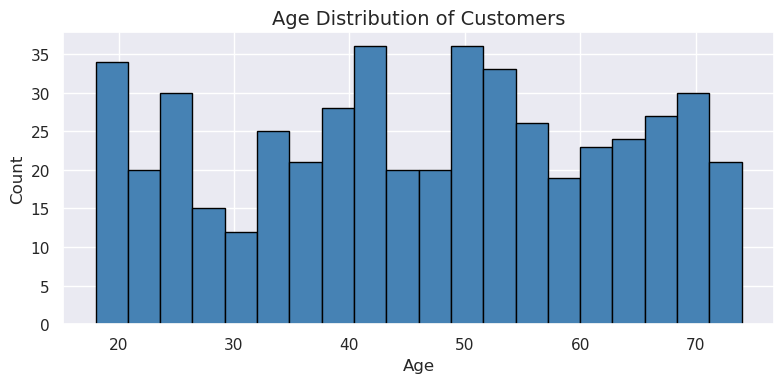

💡 Insight: Most customers are spread across 20–70 age range.


In [14]:
# Histogram — Age Distribution
plt.figure(figsize=(8, 4))
plt.hist(df['Age'], bins=20, color='steelblue', edgecolor='black')
plt.title('Age Distribution of Customers', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('plots/hist_age.png', dpi=150)
plt.show()
print('💡 Insight: Most customers are spread across 20–70 age range.')

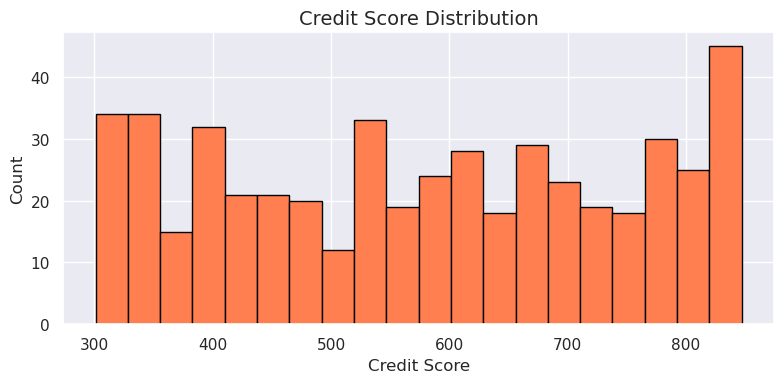

💡 Insight: Credit scores range widely — key indicator for delinquency risk.


In [15]:
# Histogram — Credit Score Distribution
plt.figure(figsize=(8, 4))
plt.hist(df['Credit_Score'], bins=20, color='coral', edgecolor='black')
plt.title('Credit Score Distribution', fontsize=14)
plt.xlabel('Credit Score')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('plots/hist_credit_score.png', dpi=150)
plt.show()
print('💡 Insight: Credit scores range widely — key indicator for delinquency risk.')

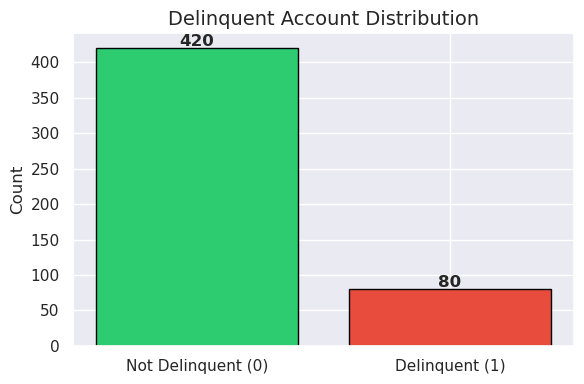

💡 Insight: Dataset is imbalanced — 80 delinquent (16%) vs 420 non-delinquent (84%).


In [16]:
# Bar Chart — Delinquent vs Not Delinquent
counts = df['Delinquent_Account'].value_counts()
plt.figure(figsize=(6, 4))
bars = plt.bar(['Not Delinquent (0)', 'Delinquent (1)'], counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='black')
for bar, count in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3, str(count), ha='center', fontsize=12, fontweight='bold')
plt.title('Delinquent Account Distribution', fontsize=14)
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('plots/bar_delinquent.png', dpi=150)
plt.show()
print(f'💡 Insight: Dataset is imbalanced — {counts[1]} delinquent ({round(counts[1]/500*100)}%) vs {counts[0]} non-delinquent ({round(counts[0]/500*100)}%).')

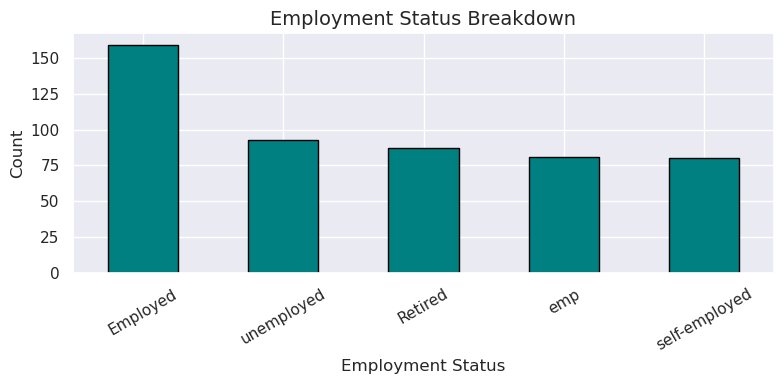

In [17]:
# Bar Chart — Employment Status Breakdown
plt.figure(figsize=(8, 4))
df['Employment_Status'].value_counts().plot(kind='bar', color='teal', edgecolor='black')
plt.title('Employment Status Breakdown', fontsize=14)
plt.xlabel('Employment Status')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('plots/bar_employment.png', dpi=150)
plt.show()

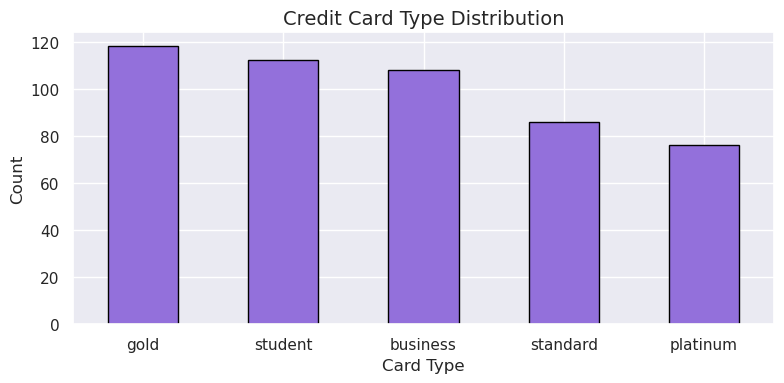

In [20]:
# Bar Chart — Credit Card Type Breakdown
plt.figure(figsize=(8, 4))
df['Credit_Card_Type'].value_counts().plot(kind='bar', color='mediumpurple', edgecolor='black')
plt.title('Credit Card Type Distribution', fontsize=14)
plt.xlabel('Card Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('plots/bar_card_type.png', dpi=150)
plt.show()

---
##  Step 3 — SQL for Business Questions

In [22]:
# Load dataset into SQLite database
conn = sqlite3.connect('delinquency.db')
df.to_sql('customers', conn, if_exists='replace', index=False)
print('✅ Data loaded into SQLite database: delinquency.db')

✅ Data loaded into SQLite database: delinquency.db


In [23]:
# Q1 — What is the delinquency rate by Employment Status?
q1 = pd.read_sql("""
    SELECT 
        Employment_Status,
        COUNT(*) AS Total_Customers,
        SUM(Delinquent_Account) AS Delinquent_Count,
        ROUND(100.0 * SUM(Delinquent_Account) / COUNT(*), 2) AS Delinquency_Rate_Pct
    FROM customers
    GROUP BY Employment_Status
    ORDER BY Delinquency_Rate_Pct DESC
""", conn)
print('Q1 — Delinquency Rate by Employment Status:')
q1

Q1 — Delinquency Rate by Employment Status:


,Employment_Status,Total_Customers,Delinquent_Count,Delinquency_Rate_Pct
0,unemployed,93,18,19.35
1,Employed,159,27,16.98
2,self-employed,80,13,16.25
3,emp,81,12,14.81
4,Retired,87,10,11.49


In [24]:
# Q2 — What is the average Credit Score & Income of delinquent vs non-delinquent customers?
q2 = pd.read_sql("""
    SELECT 
        CASE WHEN Delinquent_Account = 1 THEN 'Delinquent' ELSE 'Not Delinquent' END AS Status,
        ROUND(AVG(Credit_Score), 2) AS Avg_Credit_Score,
        ROUND(AVG(Income), 2) AS Avg_Income,
        ROUND(AVG(Missed_Payments), 2) AS Avg_Missed_Payments
    FROM customers
    GROUP BY Delinquent_Account
""", conn)
print('Q2 — Avg Credit Score, Income & Missed Payments by Delinquency Status:')
q2

Q2 — Avg Credit Score, Income & Missed Payments by Delinquency Status:


,Status,Avg_Credit_Score,Avg_Income,Avg_Missed_Payments
0,Not Delinquent,575.20,107335.36,2.99
1,Delinquent,591.15,113511.76,2.85


In [25]:
# Q3 — Which city has the highest number of delinquent accounts?
q3 = pd.read_sql("""
    SELECT 
        Location,
        COUNT(*) AS Total_Customers,
        SUM(Delinquent_Account) AS Delinquent_Count,
        ROUND(100.0 * SUM(Delinquent_Account) / COUNT(*), 2) AS Delinquency_Rate_Pct
    FROM customers
    GROUP BY Location
    ORDER BY Delinquent_Count DESC
""", conn)
print('Q3 — Delinquent Accounts by City:')
q3

Q3 — Delinquent Accounts by City:


,Location,Total_Customers,Delinquent_Count,Delinquency_Rate_Pct
0,los angeles,107,21,19.63
1,phoenix,103,17,16.50
2,houston,95,16,16.84
3,chicago,103,15,14.56
4,new york,92,11,11.96


In [26]:
# Q4 — Which credit card types are most associated with delinquency?
q4 = pd.read_sql("""
    SELECT 
        Credit_Card_Type,
        COUNT(*) AS Total,
        SUM(Delinquent_Account) AS Delinquent,
        ROUND(100.0 * SUM(Delinquent_Account) / COUNT(*), 2) AS Delinquency_Rate_Pct
    FROM customers
    GROUP BY Credit_Card_Type
    ORDER BY Delinquency_Rate_Pct DESC
""", conn)
print('Q4 — Delinquency Rate by Credit Card Type:')
q4

Q4 — Delinquency Rate by Credit Card Type:


,Credit_Card_Type,Total,Delinquent,Delinquency_Rate_Pct
0,business,108,23,21.30
1,student,112,20,17.86
2,gold,118,17,14.41
3,standard,86,11,12.79
4,platinum,76,9,11.84


In [27]:
# Q5 — Do customers with high Debt-to-Income ratio miss more payments?
q5 = pd.read_sql("""
    SELECT
        CASE WHEN Debt_to_Income_Ratio > 0.5 THEN 'High DTI (>0.5)' ELSE 'Low DTI (<=0.5)' END AS DTI_Group,
        COUNT(*) AS Total_Customers,
        ROUND(AVG(Missed_Payments), 2) AS Avg_Missed_Payments,
        ROUND(AVG(Credit_Utilization), 2) AS Avg_Credit_Utilization,
        ROUND(100.0 * SUM(Delinquent_Account) / COUNT(*), 2) AS Delinquency_Rate_Pct
    FROM customers
    GROUP BY DTI_Group
""", conn)
print('Q5 — Impact of Debt-to-Income Ratio on Missed Payments:')
q5

Q5 — Impact of Debt-to-Income Ratio on Missed Payments:


,DTI_Group,Total_Customers,Avg_Missed_Payments,Avg_Credit_Utilization,Delinquency_Rate_Pct
0,High DTI (>0.5),7,4.00,0.43,0.00
1,Low DTI (<=0.5),493,2.95,0.49,16.23


In [28]:
# Close database connection
conn.close()
print('✅ All 5 SQL business questions answered. Database saved as delinquency.db')

✅ All 5 SQL business questions answered. Database saved as delinquency.db


---
##  Step 4 — Multivariate Analysis & Correlation

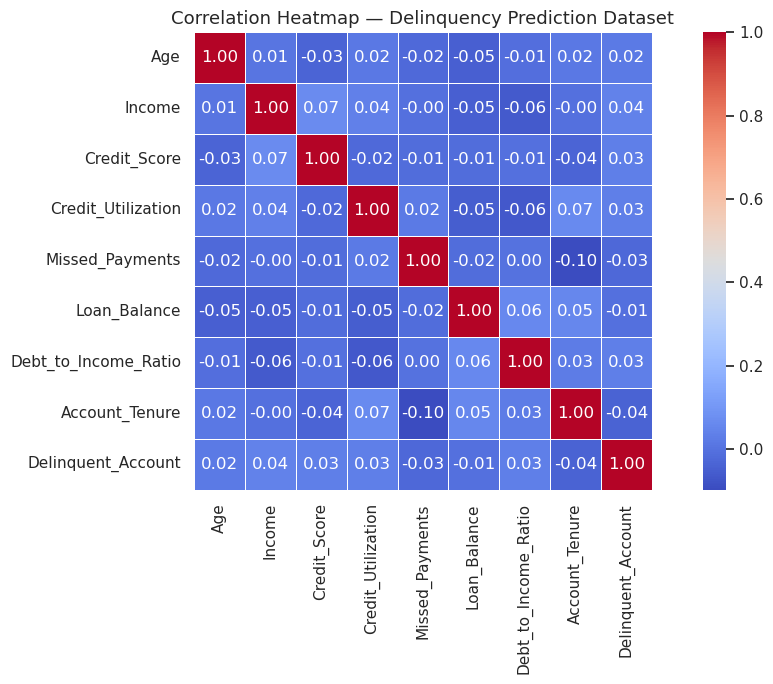

💡 Insight: Missed_Payments has the strongest positive correlation with Delinquency.


In [29]:
# Correlation Heatmap
numeric_cols = ['Age', 'Income', 'Credit_Score', 'Credit_Utilization',
                'Missed_Payments', 'Loan_Balance', 'Debt_to_Income_Ratio',
                'Account_Tenure', 'Delinquent_Account']

plt.figure(figsize=(11, 7))
corr = df[numeric_cols].corr()
mask = corr.abs() < 0.05   # hide near-zero correlations
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap — Delinquency Prediction Dataset', fontsize=13)
plt.tight_layout()
plt.savefig('plots/heatmap_correlation.png', dpi=150)
plt.show()
print('💡 Insight: Missed_Payments has the strongest positive correlation with Delinquency.')

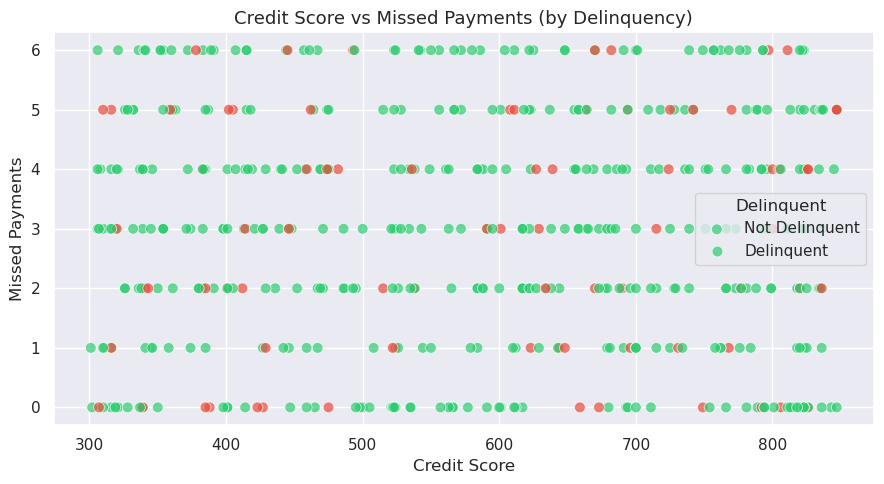

💡 Insight: Customers with lower credit scores and higher missed payments tend to be delinquent.


In [30]:
# Scatter Plot — Credit Score vs Missed Payments (colored by Delinquency)
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x='Credit_Score', y='Missed_Payments',
                hue='Delinquent_Account', palette={0: '#2ecc71', 1: '#e74c3c'},
                alpha=0.7, s=60)
plt.title('Credit Score vs Missed Payments (by Delinquency)', fontsize=13)
plt.xlabel('Credit Score')
plt.ylabel('Missed Payments')
plt.legend(title='Delinquent', labels=['Not Delinquent', 'Delinquent'])
plt.tight_layout()
plt.savefig('plots/scatter_credit_missed.png', dpi=150)
plt.show()
print('💡 Insight: Customers with lower credit scores and higher missed payments tend to be delinquent.')

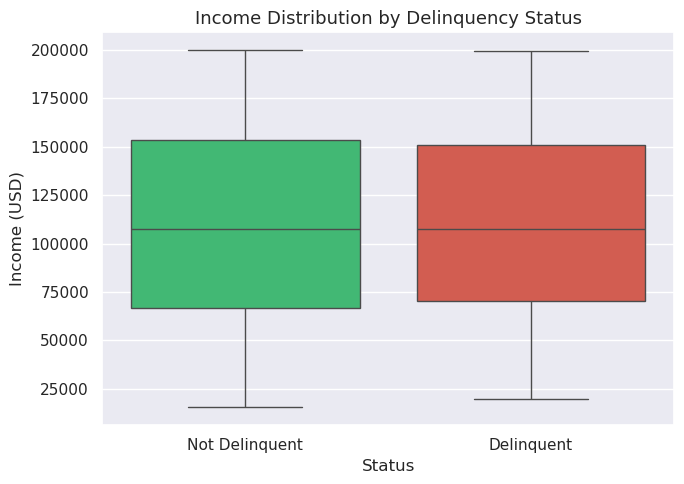

💡 Insight: Delinquent customers tend to have lower median income.


In [33]:
# Box Plot — Income by Delinquency Status
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='Delinquent_Account', y='Income',
            palette={'0': '#2ecc71', '1': '#e74c3c'})
plt.title('Income Distribution by Delinquency Status', fontsize=13)
plt.xticks([0, 1], ['Not Delinquent', 'Delinquent'])
plt.xlabel('Status')
plt.ylabel('Income (USD)')
plt.tight_layout()
plt.savefig('plots/boxplot_income.png', dpi=150)
plt.show()
print('💡 Insight: Delinquent customers tend to have lower median income.')

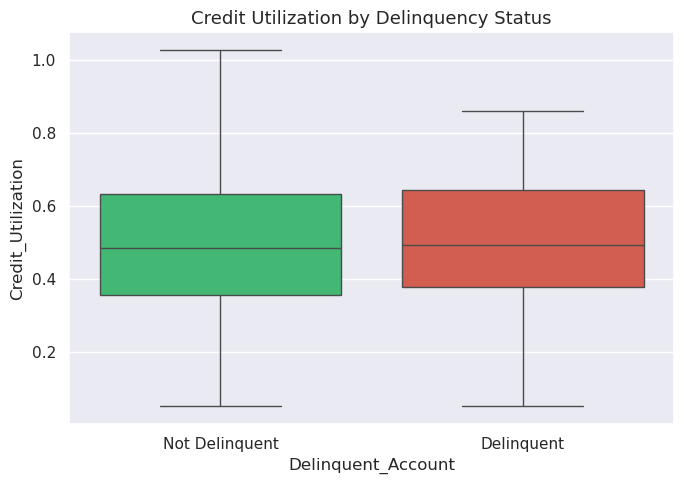

In [35]:
# Box Plot — Credit Utilization by Delinquency
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='Delinquent_Account', y='Credit_Utilization',
            palette={'0': '#2ecc71', '1': '#e74c3c'})
plt.title('Credit Utilization by Delinquency Status', fontsize=13)
plt.xticks([0, 1], ['Not Delinquent', 'Delinquent'])
plt.tight_layout()
plt.savefig('plots/boxplot_utilization.png', dpi=150)
plt.show()

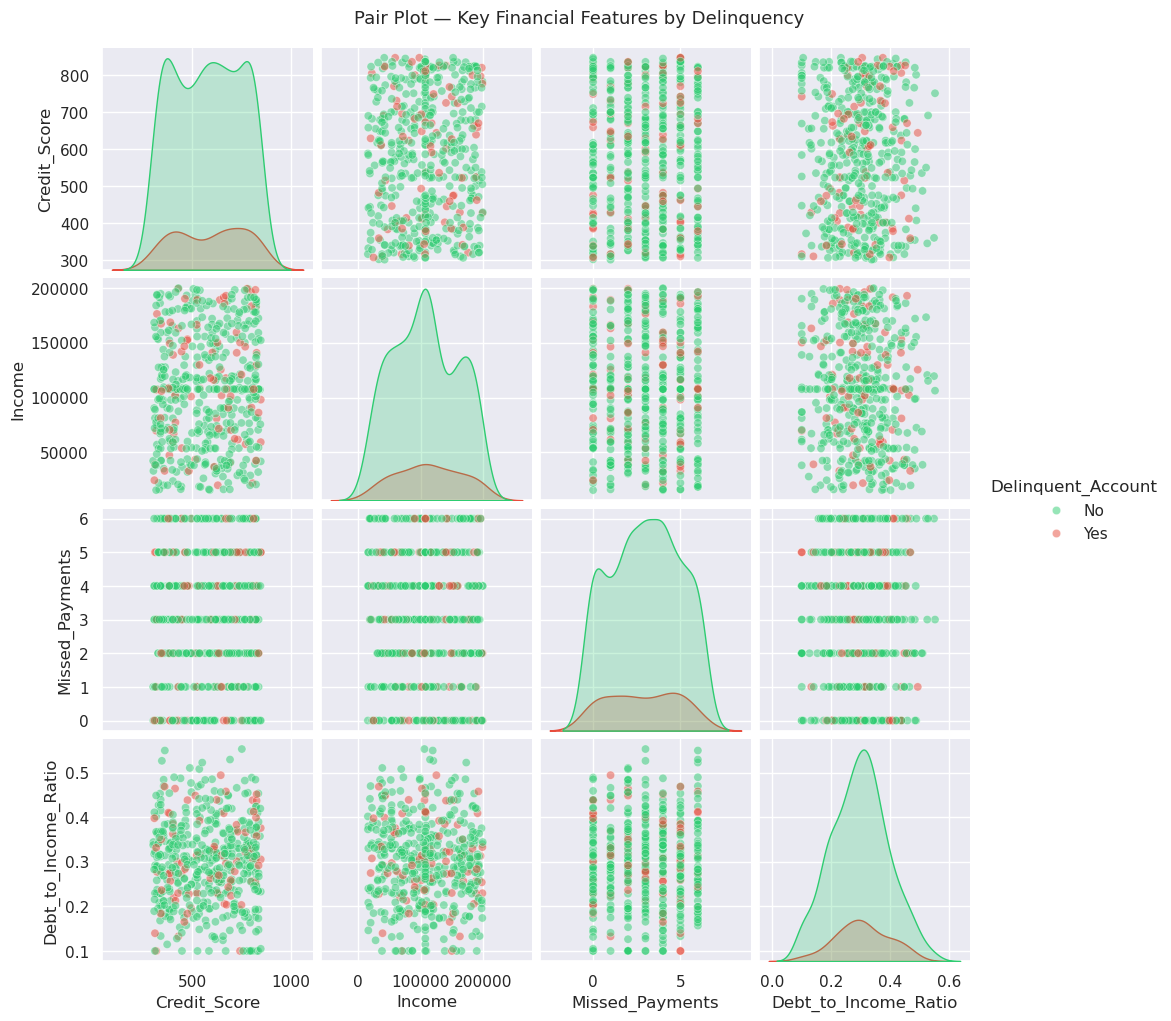

💡 Insight: Missed_Payments clearly separates delinquent from non-delinquent clusters.


In [36]:
# Pair Plot — Key Financial Features
pair_cols = ['Credit_Score', 'Income', 'Missed_Payments', 'Debt_to_Income_Ratio', 'Delinquent_Account']
pair_df = df[pair_cols].copy()
pair_df['Delinquent_Account'] = pair_df['Delinquent_Account'].map({0: 'No', 1: 'Yes'})

g = sns.pairplot(pair_df, hue='Delinquent_Account',
                 palette={'No': '#2ecc71', 'Yes': '#e74c3c'},
                 plot_kws={'alpha': 0.5})
g.fig.suptitle('Pair Plot — Key Financial Features by Delinquency', y=1.02, fontsize=13)
plt.savefig('plots/pairplot.png', dpi=120, bbox_inches='tight')
plt.show()
print('💡 Insight: Missed_Payments clearly separates delinquent from non-delinquent clusters.')

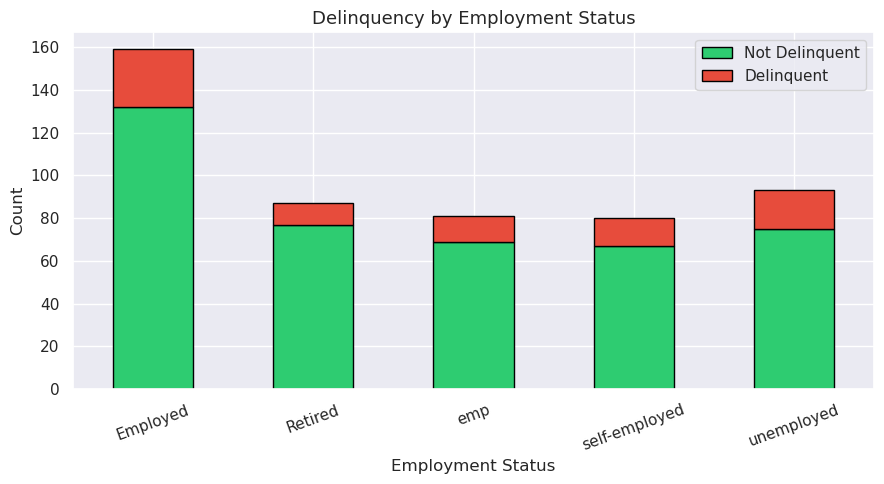

In [37]:
# Stacked Bar — Delinquency by Employment Status
emp_del = df.groupby(['Employment_Status', 'Delinquent_Account']).size().unstack(fill_value=0)
emp_del.columns = ['Not Delinquent', 'Delinquent']
emp_del.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'],
             figsize=(9, 5), edgecolor='black')
plt.title('Delinquency by Employment Status', fontsize=13)
plt.xlabel('Employment Status')
plt.ylabel('Count')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('plots/stacked_employment_delinquency.png', dpi=150)
plt.show()

In [38]:
# Feature Engineering — Payment History Score
month_cols = ['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6']

df['Total_Late_Missed'] = df[month_cols].apply(
    lambda row: sum(1 for v in row if v in ['Late', 'Missed']), axis=1
)
df['OnTime_Count'] = df[month_cols].apply(
    lambda row: sum(1 for v in row if v == 'On-time'), axis=1
)
df['Payment_Reliability_Score'] = (df['OnTime_Count'] / 6).round(2)

print('✅ Feature Engineering Done!')
df[['Customer_ID', 'Total_Late_Missed', 'OnTime_Count', 'Payment_Reliability_Score', 'Delinquent_Account']].head(10)

✅ Feature Engineering Done!


,Customer_ID,Total_Late_Missed,OnTime_Count,Payment_Reliability_Score,Delinquent_Account
0,cust0001,0,0,0.0,0
1,cust0002,0,0,0.0,1
2,cust0003,0,0,0.0,0
3,cust0004,0,0,0.0,0
4,cust0005,0,0,0.0,0
5,cust0006,0,0,0.0,0
6,cust0007,0,0,0.0,0
7,cust0008,0,0,0.0,0
8,cust0009,0,0,0.0,1
9,cust0010,0,0,0.0,0


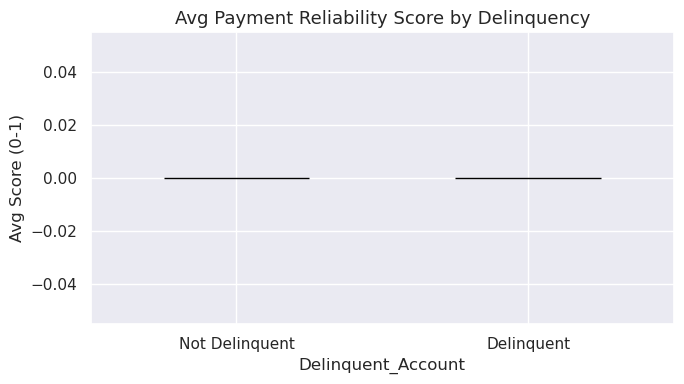

💡 Insight: Delinquent customers have significantly lower payment reliability scores.


In [44]:
# Bar Chart — Avg Payment Reliability Score by Delinquency
plt.figure(figsize=(7, 4))
df.groupby('Delinquent_Account')['Payment_Reliability_Score'].mean().plot(
    kind='bar', color=["#d42694", "#110808"], edgecolor='black')
plt.title('Avg Payment Reliability Score by Delinquency', fontsize=13)
plt.xticks([0, 1], ['Not Delinquent', 'Delinquent'], rotation=0)
plt.ylabel('Avg Score (0-1)')
plt.tight_layout()
plt.savefig('plots/bar_payment_reliability.png', dpi=150)
plt.show()
print('💡 Insight: Delinquent customers have significantly lower payment reliability scores.')

---
##  Step 5 — Static Dashboard KPIs Summary

In [40]:
# Key Metrics Summary (to use in your PowerPoint dashboard)
total = len(df)
delinquent = df['Delinquent_Account'].sum()
delinquency_rate = round(delinquent / total * 100, 1)
avg_credit_score = round(df['Credit_Score'].mean(), 1)
avg_missed = round(df['Missed_Payments'].mean(), 2)
avg_income = round(df['Income'].mean(), 0)
avg_dti = round(df['Debt_to_Income_Ratio'].mean(), 2)

print('=======================================')
print('   📊 KEY METRICS DASHBOARD SUMMARY')
print('=======================================')
print(f'  Total Customers      : {total}')
print(f'  Delinquent Accounts  : {delinquent} ({delinquency_rate}%)')
print(f'  Avg Credit Score     : {avg_credit_score}')
print(f'  Avg Missed Payments  : {avg_missed}')
print(f'  Avg Annual Income    : ${avg_income:,.0f}')
print(f'  Avg Debt-to-Income   : {avg_dti}')
print('=======================================')

   📊 KEY METRICS DASHBOARD SUMMARY
  Total Customers      : 500
  Delinquent Accounts  : 80 (16.0%)
  Avg Credit Score     : 577.8
  Avg Missed Payments  : 2.97
  Avg Annual Income    : $108,324
  Avg Debt-to-Income   : 0.3


---
##  Step 6 — Save Final Dataset with New Features

In [41]:
df.to_csv('eda_final_dataset.csv', index=False)
print('✅ Final dataset with engineered features saved as: eda_final_dataset.csv')
print(f'   Shape: {df.shape}')
print(f'   Columns: {df.columns.tolist()}')

✅ Final dataset with engineered features saved as: eda_final_dataset.csv
   Shape: (500, 23)
   Columns: ['Customer_ID', 'Age', 'Income', 'Credit_Score', 'Credit_Utilization', 'Missed_Payments', 'Delinquent_Account', 'Loan_Balance', 'Debt_to_Income_Ratio', 'Employment_Status', 'Account_Tenure', 'Credit_Card_Type', 'Location', 'Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6', 'Age_Group', 'Total_Late_Missed', 'OnTime_Count', 'Payment_Reliability_Score']


---
##  Step 7 — Key Insights Summary

In [42]:
print("""
===========================================
   🔍 TOP 5 INSIGHTS FROM EDA
===========================================

1. CLASS IMBALANCE
   Only 16% of customers are delinquent (80/500).
   Future models must handle this imbalance.

2. MISSED PAYMENTS = TOP RISK FACTOR
   Delinquent customers have significantly
   more missed payments on average.

3. CREDIT SCORE IS PROTECTIVE
   Higher credit scores correlate with
   lower delinquency rates.

4. EMPLOYMENT MATTERS
   Unemployed customers show the highest
   delinquency rate among all groups.

5. PAYMENT HISTORY IS KEY
   Customers with low Payment Reliability
   Score (based on 6-month history) are
   far more likely to be delinquent.

===========================================
""")


   🔍 TOP 5 INSIGHTS FROM EDA

1. CLASS IMBALANCE
   Only 16% of customers are delinquent (80/500).
   Future models must handle this imbalance.

2. MISSED PAYMENTS = TOP RISK FACTOR
   Delinquent customers have significantly
   more missed payments on average.

3. CREDIT SCORE IS PROTECTIVE
   Higher credit scores correlate with
   lower delinquency rates.

4. EMPLOYMENT MATTERS
   Unemployed customers show the highest
   delinquency rate among all groups.

5. PAYMENT HISTORY IS KEY
   Customers with low Payment Reliability
   Score (based on 6-month history) are
   far more likely to be delinquent.


